# 02 — Analysis

Main effects in both directions, interactions against an explicit null, and
dispersion across seeds. No GPU needed.

Two rules the tool enforces, worth remembering when reading the output. Where
the from-below and from-above estimates of a main effect **disagree**, neither
may be quoted alone — the disagreement *is* the interaction. And nothing is
quotable without dispersion, so a partial campaign shows `nan` error bars and
`UNDETERMINED` rather than a confident-looking number.


## 1. Drive and repo

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# ---------------------------------------------------------------------------
# The one place paths are defined. Everything else derives from DRIVE_ROOT.
#
#   e3dgsuw/
#     dataset/     the four scenes (original) + undistorted/  <- created below
#     dense/       M1 clouds, with SHA-256 sidecars
#     runs/        <cell>/<scene>/s<seed>/  -- one run, all of it together
#     analysis/    analyse.py output, figures, tables
#     run_ledger.json
# ---------------------------------------------------------------------------
DRIVE_ROOT   = '/content/drive/MyDrive/e3dgsuw'
DATASET_DIR  = f'{DRIVE_ROOT}/dataset'
DATA_UNDIST  = f'{DATASET_DIR}/undistorted'
DENSE_DIR    = f'{DRIVE_ROOT}/dense'
ANALYSIS_DIR = f'{DRIVE_ROOT}/analysis'

# Training reads from local disk, not Drive: the scene loader pulls every image
# at startup, and Drive's FUSE layer makes that far slower than a single copy.
LOCAL_DATA   = '/content/data'

REPO_URL  = 'https://github.com/dinanirham/An-Efficient-3D-Gaussian-Splatting-for-Underwater-3D-Reconstruction.git'
REPO_DIR  = '/content/e3dgsuw'
IMPL_DIR  = f'{REPO_DIR}/implementation'
SCENES    = ['Curasao', 'IUI3-RedSea', 'JapaneseGradens-RedSea', 'Panama']

import os
assert os.path.isdir(DRIVE_ROOT), (
    f'{DRIVE_ROOT} not found. Check the folder name, or edit DRIVE_ROOT above.')
for d in (DATA_UNDIST, DENSE_DIR, f'{DRIVE_ROOT}/runs', ANALYSIS_DIR):
    os.makedirs(d, exist_ok=True)

# Export them so the `!` cells below resolve "$DRIVE_ROOT" as a real shell
# variable. Relying on IPython to substitute notebook variables into magics
# works until it doesn't, and when it doesn't it substitutes nothing and the
# command runs against a silently truncated path rather than failing.
os.environ.update(
    DRIVE_ROOT=DRIVE_ROOT, DATASET_DIR=DATASET_DIR, DATA_UNDIST=DATA_UNDIST,
    DENSE_DIR=DENSE_DIR, ANALYSIS_DIR=ANALYSIS_DIR, LOCAL_DATA=LOCAL_DATA,
    REPO_DIR=REPO_DIR, IMPL_DIR=IMPL_DIR,
)


def find_originals():
    """Locate the four scenes under dataset/, however they were arranged.

    Accepts the scenes directly under dataset/, or nested one level (e.g.
    dataset/SeathruNeRF_dataset/). Returns the directory that contains them.
    """
    candidates = [DATASET_DIR] + [
        os.path.join(DATASET_DIR, d) for d in sorted(os.listdir(DATASET_DIR))
        if os.path.isdir(os.path.join(DATASET_DIR, d)) and d != 'undistorted'
    ]
    for base in candidates:
        if all(os.path.isdir(os.path.join(base, s)) for s in SCENES):
            return base
    return None


DATA_ORIG = find_originals()

# verify_undistort's T1 -- the check that would catch the undistortion gap --
# reads the *original* dataset. Point it at wherever it actually landed on
# Drive, or T1 reports "dataset not found" and the one check that matters here
# quietly stops testing anything.
if DATA_ORIG:
    os.environ['E3DGSUW_DATASET'] = DATA_ORIG

print('drive root :', DRIVE_ROOT)
print('originals  :', DATA_ORIG or 'NOT FOUND')
print('undistorted:', DATA_UNDIST)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
drive root : /content/drive/MyDrive/e3dgsuw
originals  : /content/drive/MyDrive/e3dgsuw/dataset/SeaThruNeRF_dataset
undistorted: /content/drive/MyDrive/e3dgsuw/dataset/undistorted


In [2]:
import os, subprocess

# Private repo? Add a Colab secret named GITHUB_TOKEN (key icon in the left
# sidebar) with a fine-grained read token, and toggle notebook access on.
# Read from Secrets rather than pasted into the cell: a pasted token is saved
# inside the .ipynb, which then travels wherever the notebook does.
GITHUB_TOKEN = None
try:
    from google.colab import userdata
    GITHUB_TOKEN = userdata.get('GITHUB_TOKEN') or None
    print('GITHUB_TOKEN: loaded from Colab Secrets')
except ImportError:
    pass                                  # not running under Colab
except Exception as e:                    # secret absent, or access not granted
    print(f'GITHUB_TOKEN: not available ({type(e).__name__}) -- '
          'fine for a public repo')

url = REPO_URL
if GITHUB_TOKEN:
    url = REPO_URL.replace('https://', f'https://{GITHUB_TOKEN}@')

# Never let git fall back to an interactive credential prompt: in a notebook it
# hangs the cell indefinitely with nothing on screen to say why.
env = {**os.environ, 'GIT_TERMINAL_PROMPT': '0'}


def _redact(s):
    """Strip the token from git output -- git echoes the remote URL on failure,
    and notebook outputs are saved to the file and shared with it."""
    return s.replace(GITHUB_TOKEN, '***') if GITHUB_TOKEN else s


if os.path.isdir(REPO_DIR) and not os.path.isdir(f'{REPO_DIR}/.git'):
    raise RuntimeError(
        f'{REPO_DIR} exists but is not a git checkout -- probably a clone that '
        f'died partway. Delete it and re-run this cell.')

if not os.path.exists(REPO_DIR):
    r = subprocess.run(['git','clone','--depth','1',url,REPO_DIR],
                       capture_output=True, text=True, env=env)
    if r.returncode != 0:
        raise RuntimeError(
            'clone failed. If the repository is private, add a GITHUB_TOKEN '
            'secret in Colab and grant this notebook access.\n'
            f'{_redact(r.stderr)[-800:]}')
else:
    # Repoint the remote before pulling. The stored URL was written by an
    # earlier clone, which may have run without a token (or with a stale one);
    # injecting the token into `url` alone never reaches the pull.
    subprocess.run(['git','-C',REPO_DIR,'remote','set-url','origin',url],
                   check=True, env=env)
    r = subprocess.run(['git','-C',REPO_DIR,'pull','--ff-only'],
                       capture_output=True, text=True, env=env)
    if r.returncode != 0:
        raise RuntimeError(
            'pull failed. If the repository is private, check the GITHUB_TOKEN '
            'secret is set and this notebook has access.\n'
            f'{_redact(r.stderr)[-800:]}')

# Fail here, naming the directory, rather than letting a later cell run from
# whatever the working directory happened to be.
assert os.path.isdir(IMPL_DIR), (
    f'clone produced no {IMPL_DIR}. Contents of {REPO_DIR}: '
    f'{sorted(os.listdir(REPO_DIR)) if os.path.isdir(REPO_DIR) else "missing"}')

os.chdir(IMPL_DIR)
print(subprocess.run(['git','-C',REPO_DIR,'log','--oneline','-1'],
                     capture_output=True, text=True).stdout.strip())
print('cwd:', os.getcwd())


GITHUB_TOKEN: loaded from Colab Secrets
888e55e docs: analysis plan for campaign 2026-09, written before the bundle is opened
cwd: /content/e3dgsuw/implementation


In [3]:
# Builds diff_gaussian_rasterization_ms and simple_knn against whatever torch
# Colab ships -- deliberately NOT installing our own, which would risk a
# mismatch between torch's CUDA and the toolkit the extensions compile with.
# Takes a few minutes; must be repeated each session.
#
# chdir explicitly rather than via `%cd $IMPL_DIR`: a magic whose variable fails
# to expand reports the *current* directory and continues, so the build then
# runs from the wrong place and fails two steps later with a bare
# "tools/setup_colab.sh: No such file or directory".
import os
assert os.path.isdir(IMPL_DIR), (
    f'{IMPL_DIR} not found -- run the "Clone the repository" cell above first.')
os.chdir(IMPL_DIR)
print('building in', os.getcwd())
!bash tools/setup_colab.sh

building in /content/e3dgsuw/implementation
 repo root        : /content/e3dgsuw
 implementation   : /content/e3dgsuw/implementation
 arch list        : 8.0+PTX

--- GPU ---
NVIDIA A100-SXM4-40GB, 40960 MiB, 580.82.07

--- sanity: the reference submodules must be present ---
  ok: /content/e3dgsuw/mini-splatting/submodules/diff-gaussian-rasterization_ms
  ok: /content/e3dgsuw/mini-splatting/submodules/simple-knn
  ok: /content/e3dgsuw/mini-splatting/submodules/diff-gaussian-rasterization_ms/third_party/glm

--- python deps Colab does not ship ---
--- RoMa (M1 only) ---
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
    fused-local-corr installed but will not load:
            from . import _C, ops
        ImportError: libcudart.so.13: cannot open shared object file: No such file or directory
    removed it; roma_init uses the pure-torch correlation
    (slower, same result)
    romatch ok


--- tool

## 2. Campaign state

In [4]:
!python -m tools.run_ledger status --output_root "$DRIVE_ROOT"


ledger : /content/drive/MyDrive/e3dgsuw/run_ledger.json
budget : 200000
total  : 120 runs  done=120

  S0 (SS          ) done=12
  S1 (A0          ) done=12
  S2 (A2          ) done=12
  S3 (A1,A3       ) done=24
  S4 (A4,A5,A6    ) done=36
  S5 (A7          ) done=12
  S6 (A0D         ) done=12


## 3. Contrasts

Quality metrics combine additively; ratio measures (storage, primitive count,
frame rate) combine multiplicatively, in log space.


In [5]:
!python -m tools.analyse \
    --output_root "$DRIVE_ROOT" \
    --weighting unweighted \
    --json "$ANALYSIS_DIR/analysis_unweighted.json"


loaded 96 runs: 8 cells, 4 scenes

  *** MEDIUM-MODEL COLLAPSE: 9 of 96 runs lost an attenuation channel permanently. ***
        A2/Curasao/s1: G,B clamped at zero
        A2/JapaneseGradens-RedSea/s0: B clamped at zero
        A2/JapaneseGradens-RedSea/s1: B clamped at zero
        A2/Panama/s1: B clamped at zero
        A2/Panama/s2: B clamped at zero
        A6/Curasao/s0: B clamped at zero
        A6/Curasao/s1: G,B clamped at zero
        A6/JapaneseGradens-RedSea/s1: B clamped at zero
        A6/Panama/s2: B clamped at zero
      6 cell+scene group(s) MIX collapsed and intact seeds. A mean over these averages two physically different models:
        A2/Curasao: 1 of 3 seeds collapsed
        A2/JapaneseGradens-RedSea: 2 of 3 seeds collapsed
        A2/Panama: 2 of 3 seeds collapsed
        A6/Curasao: 2 of 3 seeds collapsed
        A6/JapaneseGradens-RedSea: 1 of 3 seeds collapsed
        A6/Panama: 1 of 3 seeds collapsed
      Fidelity metrics cannot separate them -- they score

In [6]:
# Scene image counts are unequal (21/29/20/18), so the two weightings differ by
# more than many ablation differences in this literature. Reporting both
# removes an easy source of disagreement.
!python -m tools.analyse \
    --output_root "$DRIVE_ROOT" \
    --weighting image_weighted \
    --json "$ANALYSIS_DIR/analysis_image_weighted.json"


loaded 96 runs: 8 cells, 4 scenes

  *** MEDIUM-MODEL COLLAPSE: 9 of 96 runs lost an attenuation channel permanently. ***
        A2/Curasao/s1: G,B clamped at zero
        A2/JapaneseGradens-RedSea/s0: B clamped at zero
        A2/JapaneseGradens-RedSea/s1: B clamped at zero
        A2/Panama/s1: B clamped at zero
        A2/Panama/s2: B clamped at zero
        A6/Curasao/s0: B clamped at zero
        A6/Curasao/s1: G,B clamped at zero
        A6/JapaneseGradens-RedSea/s1: B clamped at zero
        A6/Panama/s2: B clamped at zero
      6 cell+scene group(s) MIX collapsed and intact seeds. A mean over these averages two physically different models:
        A2/Curasao: 1 of 3 seeds collapsed
        A2/JapaneseGradens-RedSea: 2 of 3 seeds collapsed
        A2/Panama: 2 of 3 seeds collapsed
        A6/Curasao: 2 of 3 seeds collapsed
        A6/JapaneseGradens-RedSea: 1 of 3 seeds collapsed
        A6/Panama: 1 of 3 seeds collapsed
      Fidelity metrics cannot separate them -- they score

## 4. The central hypothesis (H4)

Not a between-cell comparison: the medium coefficients across the
simplification boundary in A2. A jump in β at 15 000 is the signature of the
identifiability failure.

**The right x-axis companion is `zr_cv`, not `z_max`.** `z_min`/`z_max` come
from the single view sampled at that iteration, so they are one draw from the
distribution the argument is about — measured to differ from the cross-frame
mean by a median 6.8% and a maximum 38.2%. A trend read from them carries an
uncontrolled term. The `zr_*` columns (CD-27) sweep every training view and
carry the distribution itself; `zr_cv` is its dispersion, dimensionless and
therefore comparable across scenes.

The prediction under test: **collapse tracks the change in `zr_cv` across the
event, not the change in primitive count.** A distribution that merely
translates leaves β's compromise attainable; one that broadens does not. If the
ratio fails to separate the collapsed runs from the intact ones, the
identifiability account is wrong and should be withdrawn rather than qualified.


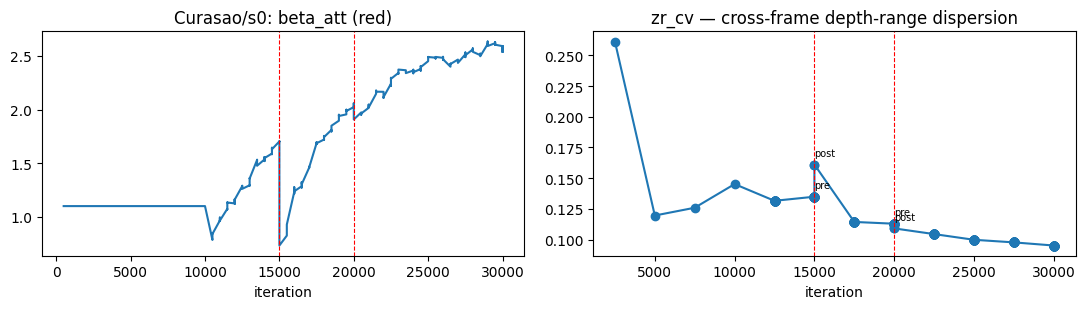

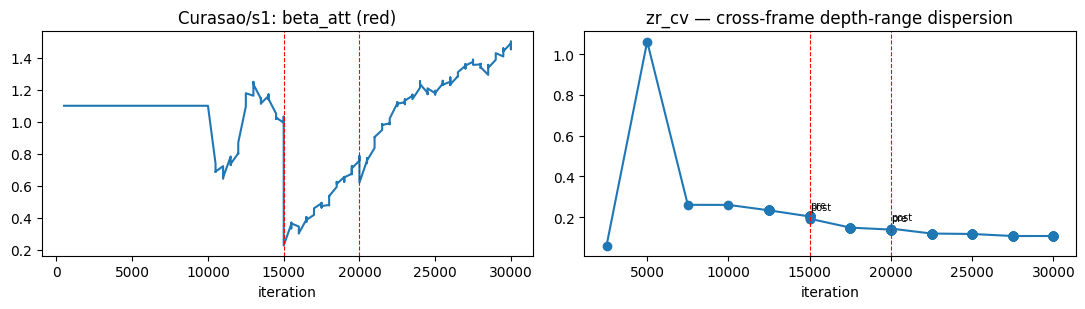

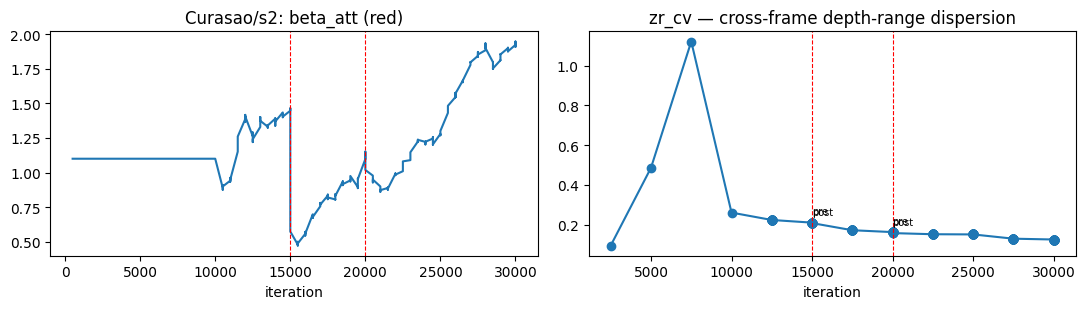

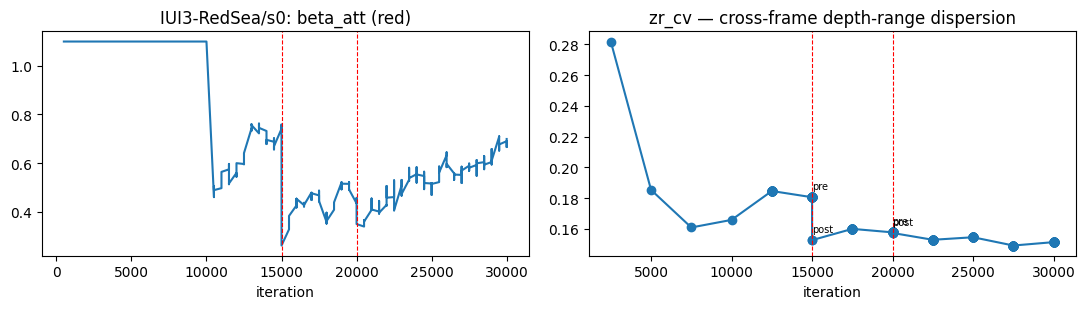

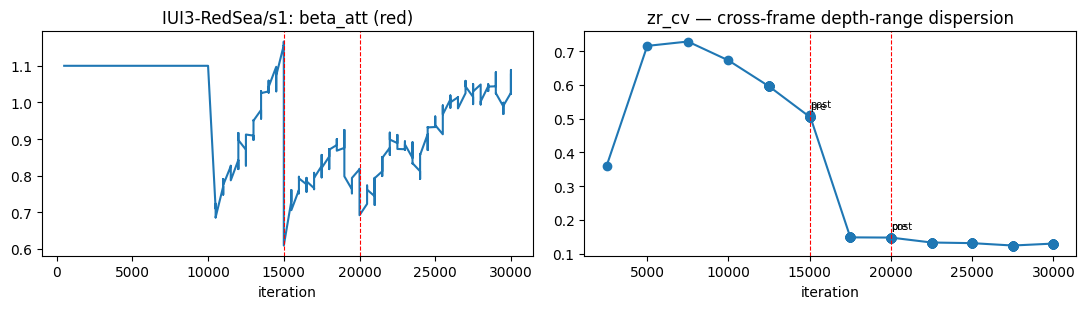

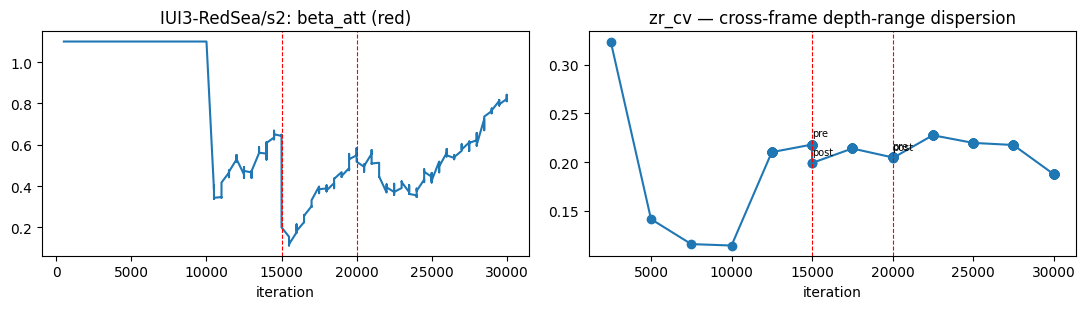

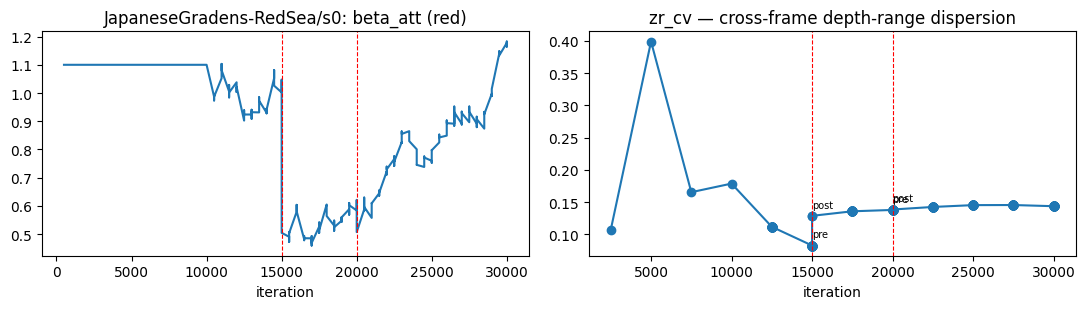

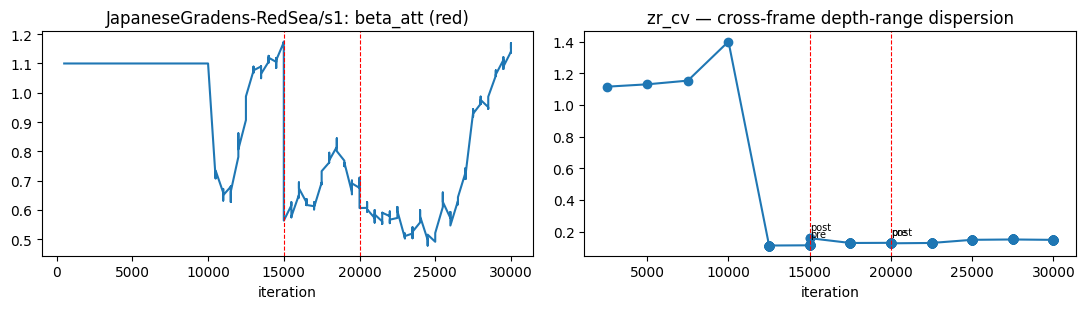

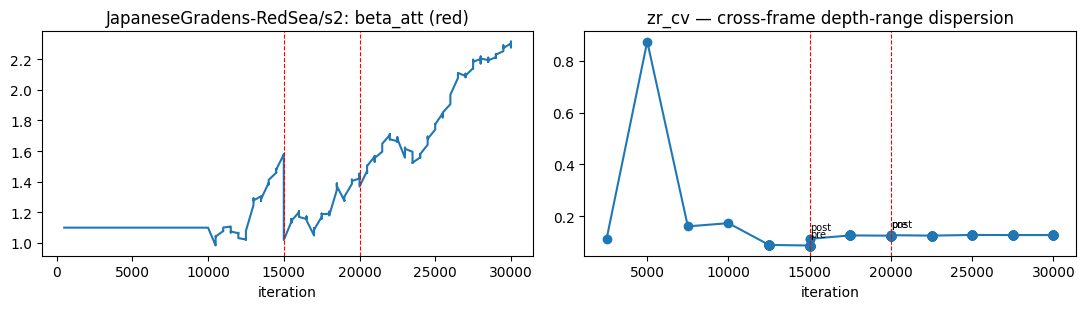

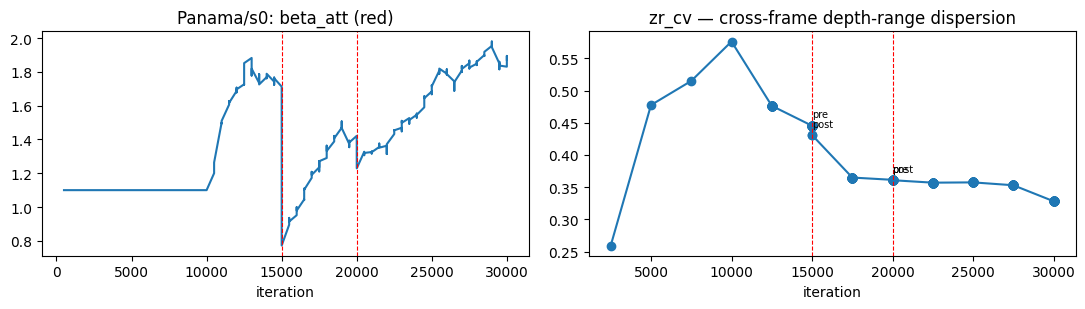

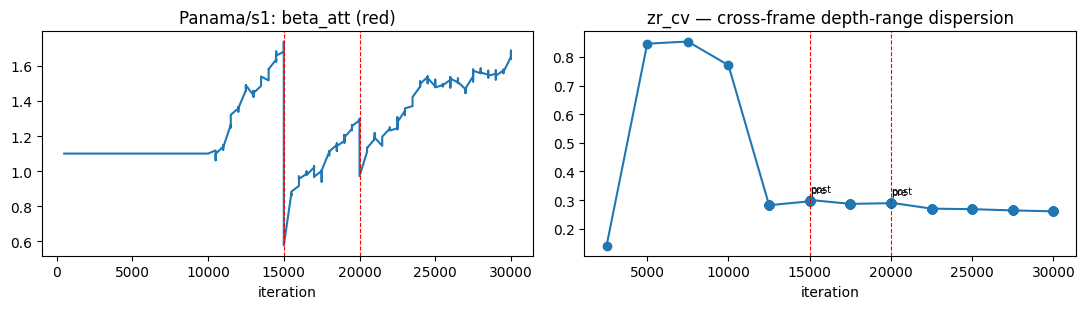

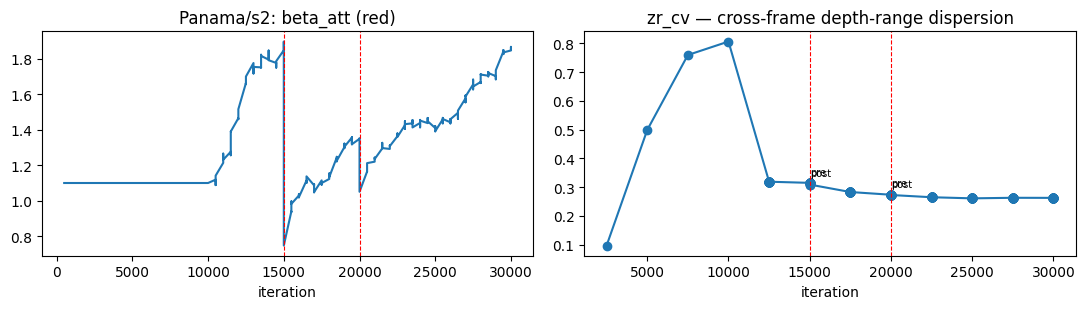

  A7/Curasao/s0                       20000     0.1611     0.0694   0.431  yes
  A7/Curasao/s1                       15000     0.1060     0.1060   1.000  yes
  A7/Curasao/s1                       20000     0.0820     0.3133   3.820  yes
  A7/Curasao/s2                       15000     0.1023     0.0959   0.938  no
  A7/Curasao/s2                       20000     0.0490     0.3561   7.273  no
  A7/IUI3-RedSea/s0                   15000     0.0745     0.0725   0.972  yes
  A7/IUI3-RedSea/s0                   20000     0.0706     0.0672   0.952  yes
  A7/IUI3-RedSea/s1                   15000     0.0559     0.0531   0.950  no
  A7/IUI3-RedSea/s1                   20000     0.0648     0.0631   0.975  no
  A7/IUI3-RedSea/s2                   15000     0.0649     0.0563   0.867  yes
  A7/IUI3-RedSea/s2                   20000     0.0658     0.0642   0.975  yes
  A7/JapaneseGradens-RedSea/s0        15000     0.1079     0.1070   0.991  yes
  A7/JapaneseGradens-RedSea/s0        20000     0.1024  

In [7]:
import glob, csv
import matplotlib.pyplot as plt

paths = sorted(glob.glob(f'{DRIVE_ROOT}/runs/A2/*/s*/diagnostics.csv'))
if not paths:
    print('No A2 runs yet — that is stage S2.')

def _f(r, k):
    v = r.get(k, '')
    return float(v) if v not in ('', None) else None

for p in paths:
    rows = list(csv.DictReader(open(p)))
    beta_rows = [r for r in rows if r.get('beta_att_r')]
    if not beta_rows:
        continue
    scene = p.split('/runs/A2/')[1].split('/')[0]
    seed  = p.split('/s')[-1].split('/')[0]

    it   = [int(r['iteration']) for r in beta_rows]
    beta = [float(r['beta_att_r']) for r in beta_rows]

    # The cross-frame sweep fires only at the boundaries and on a coarse
    # interval, so it is a handful of points rather than a dense trace.
    sw = [(int(r['iteration']), _f(r, 'zr_cv'), r.get('event', ''))
          for r in rows if _f(r, 'zr_cv') is not None]

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
    ax[0].plot(it, beta)
    for x in (15000, 20000):
        ax[0].axvline(x, ls='--', c='r', lw=0.8)
    ax[0].set_title(f'{scene}/s{seed}: beta_att (red)')

    if sw:
        ax[1].plot([x for x, _, _ in sw], [c for _, c, _ in sw], 'o-')
        for x, c, ev in sw:
            if ev in ('pre_simp', 'post_simp'):
                ax[1].annotate(ev.split('_')[0], (x, c), fontsize=7,
                               xytext=(0, 6), textcoords='offset points')
        ax[1].set_title('zr_cv — cross-frame depth-range dispersion')
    else:
        ax[1].text(0.5, 0.5, 'no cross-frame sweep\n(run predates CD-27)',
                   ha='center', va='center', transform=ax[1].transAxes)
        ax[1].set_title('zr_cv — not measured')
    for x in (15000, 20000):
        ax[1].axvline(x, ls='--', c='r', lw=0.8)

    for a in ax:
        a.set_xlabel('iteration')
    plt.tight_layout()
    plt.savefig(f'{ANALYSIS_DIR}/h4_{scene}_s{seed}.png', dpi=140)
    plt.show()

# The ratio itself, beside the collapse verdict, for every run that carries it.
!python -m tools.medium_collapse --output_root "$DRIVE_ROOT" 2>&1 | tail -30


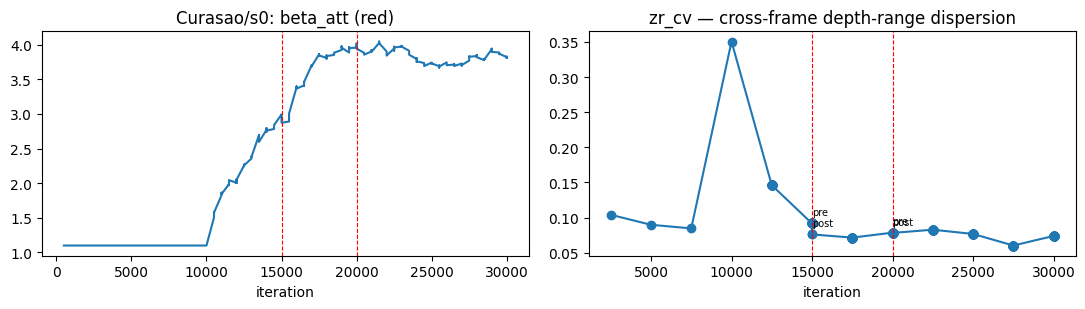

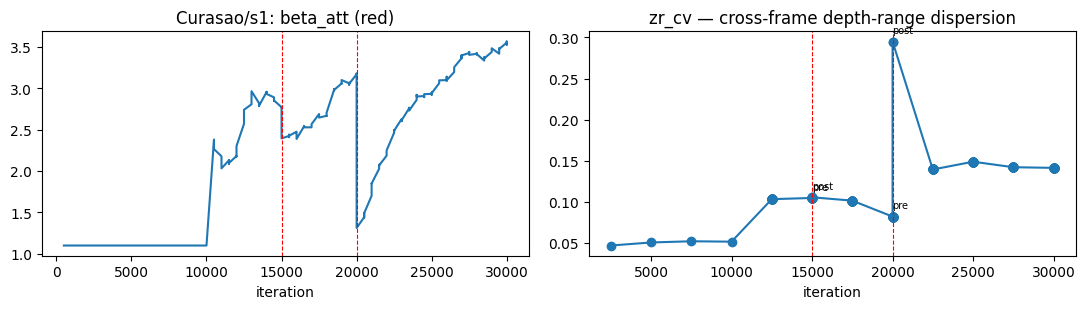

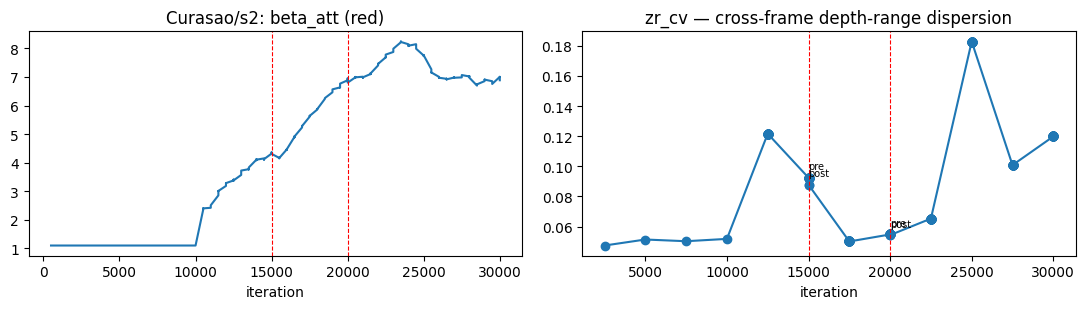

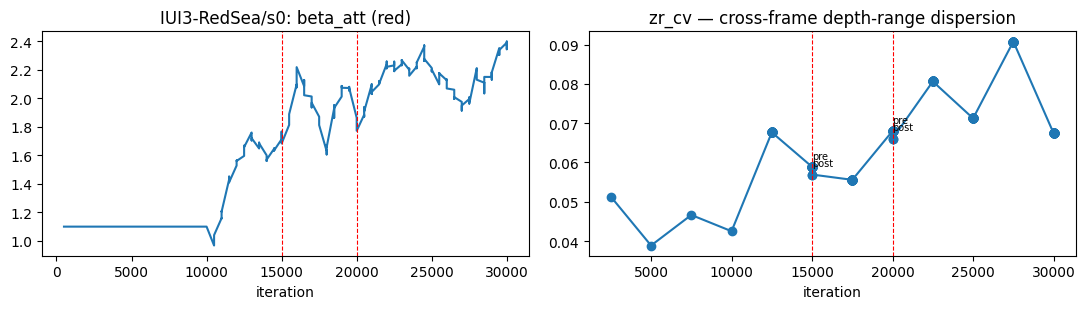

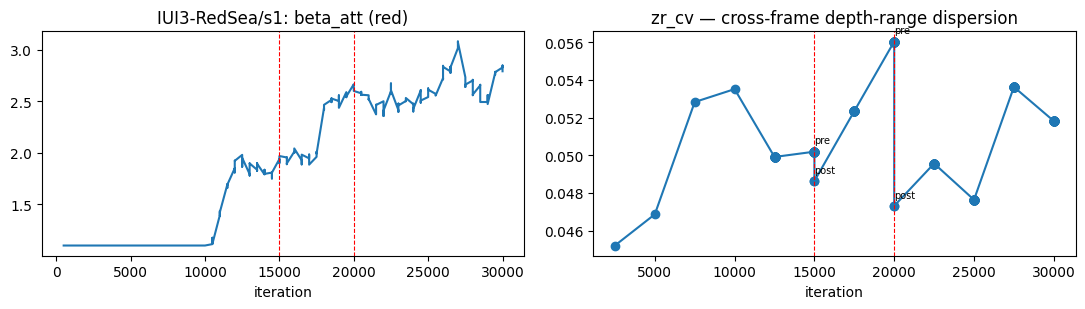

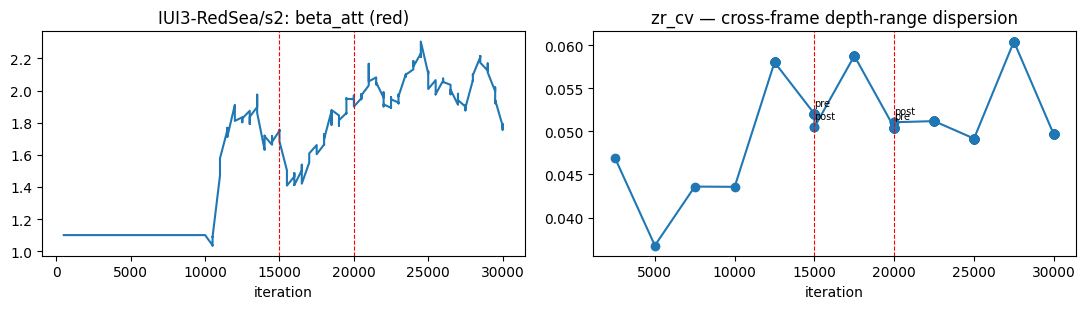

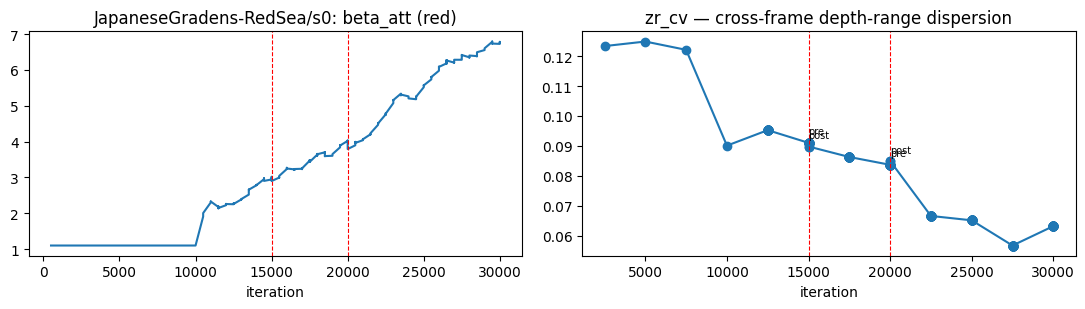

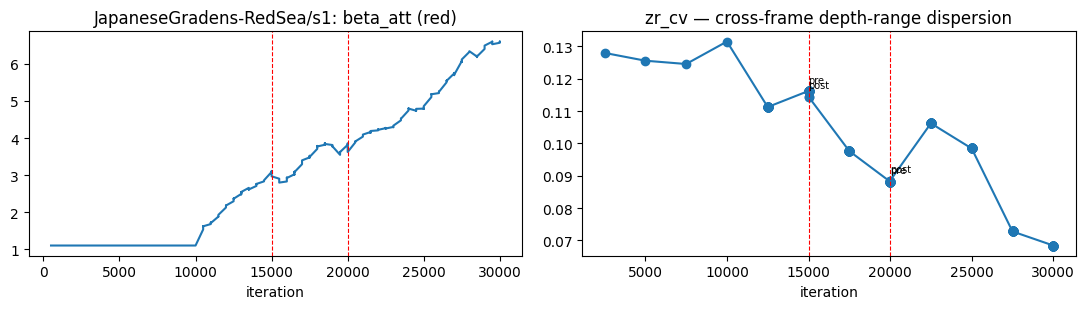

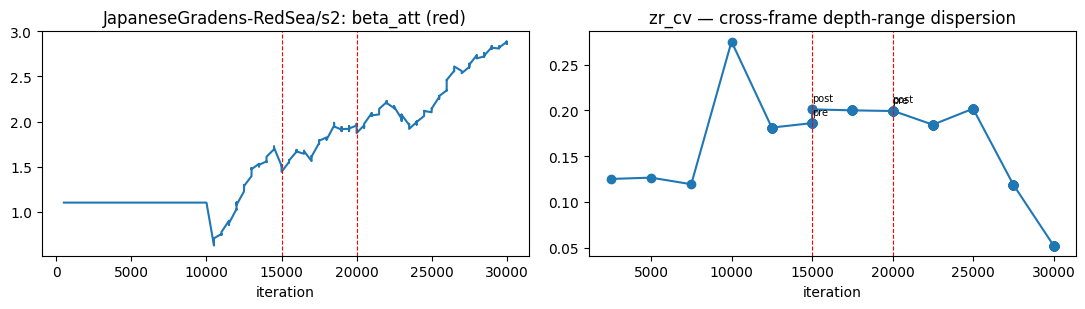

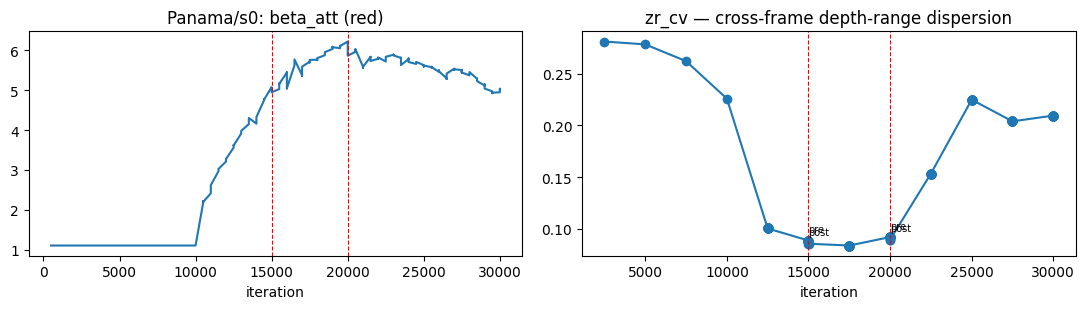

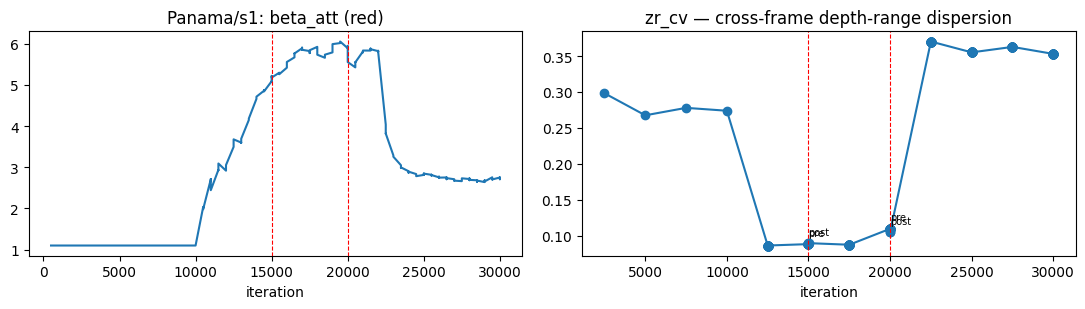

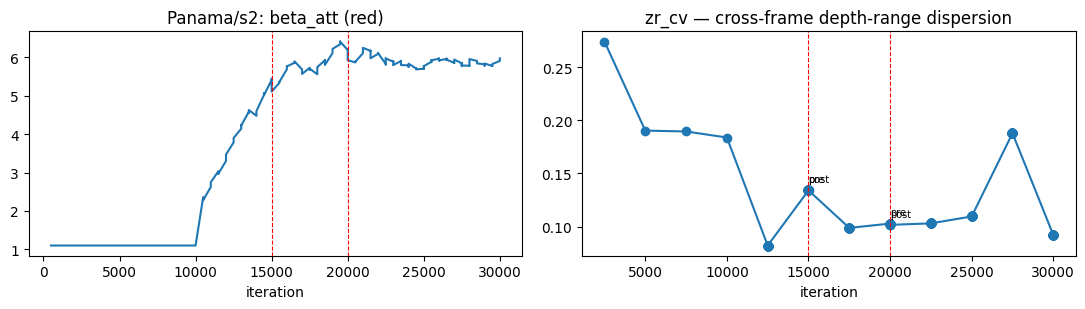

  A7/Curasao/s0                       20000     0.1611     0.0694   0.431  yes
  A7/Curasao/s1                       15000     0.1060     0.1060   1.000  yes
  A7/Curasao/s1                       20000     0.0820     0.3133   3.820  yes
  A7/Curasao/s2                       15000     0.1023     0.0959   0.938  no
  A7/Curasao/s2                       20000     0.0490     0.3561   7.273  no
  A7/IUI3-RedSea/s0                   15000     0.0745     0.0725   0.972  yes
  A7/IUI3-RedSea/s0                   20000     0.0706     0.0672   0.952  yes
  A7/IUI3-RedSea/s1                   15000     0.0559     0.0531   0.950  no
  A7/IUI3-RedSea/s1                   20000     0.0648     0.0631   0.975  no
  A7/IUI3-RedSea/s2                   15000     0.0649     0.0563   0.867  yes
  A7/IUI3-RedSea/s2                   20000     0.0658     0.0642   0.975  yes
  A7/JapaneseGradens-RedSea/s0        15000     0.1079     0.1070   0.991  yes
  A7/JapaneseGradens-RedSea/s0        20000     0.1024  

In [8]:
import glob, csv
import matplotlib.pyplot as plt

paths = sorted(glob.glob(f'{DRIVE_ROOT}/runs/A4/*/s*/diagnostics.csv'))
if not paths:
    print('No A4 runs yet — that is stage S2.')

def _f(r, k):
    v = r.get(k, '')
    return float(v) if v not in ('', None) else None

for p in paths:
    rows = list(csv.DictReader(open(p)))
    beta_rows = [r for r in rows if r.get('beta_att_r')]
    if not beta_rows:
        continue
    scene = p.split('/runs/A4/')[1].split('/')[0]
    seed  = p.split('/s')[-1].split('/')[0]

    it   = [int(r['iteration']) for r in beta_rows]
    beta = [float(r['beta_att_r']) for r in beta_rows]

    # The cross-frame sweep fires only at the boundaries and on a coarse
    # interval, so it is a handful of points rather than a dense trace.
    sw = [(int(r['iteration']), _f(r, 'zr_cv'), r.get('event', ''))
          for r in rows if _f(r, 'zr_cv') is not None]

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
    ax[0].plot(it, beta)
    for x in (15000, 20000):
        ax[0].axvline(x, ls='--', c='r', lw=0.8)
    ax[0].set_title(f'{scene}/s{seed}: beta_att (red)')

    if sw:
        ax[1].plot([x for x, _, _ in sw], [c for _, c, _ in sw], 'o-')
        for x, c, ev in sw:
            if ev in ('pre_simp', 'post_simp'):
                ax[1].annotate(ev.split('_')[0], (x, c), fontsize=7,
                               xytext=(0, 6), textcoords='offset points')
        ax[1].set_title('zr_cv — cross-frame depth-range dispersion')
    else:
        ax[1].text(0.5, 0.5, 'no cross-frame sweep\n(run predates CD-27)',
                   ha='center', va='center', transform=ax[1].transAxes)
        ax[1].set_title('zr_cv — not measured')
    for x in (15000, 20000):
        ax[1].axvline(x, ls='--', c='r', lw=0.8)

    for a in ax:
        a.set_xlabel('iteration')
    plt.tight_layout()
    plt.savefig(f'{ANALYSIS_DIR}/h4_{scene}_s{seed}.png', dpi=140)
    plt.show()

# The ratio itself, beside the collapse verdict, for every run that carries it.
!python -m tools.medium_collapse --output_root "$DRIVE_ROOT" 2>&1 | tail -30


## 4b. The rest of the instrument panel

These four ran by hand throughout the first campaign, which is why they were
easy to forget. Each answers a question the contrasts cannot.


In [9]:
# Everything in one table: fidelity, cost, dispersion, per scene and per cell.
!python -m tools.collect_results --output_root "$DRIVE_ROOT" \
    --out_dir "$ANALYSIS_DIR"


120 runs (120 complete), 16 metrics
  9 run(s) with a collapsed attenuation channel -- see results_summary.md
  /content/drive/MyDrive/e3dgsuw/analysis/results_runs.csv
  /content/drive/MyDrive/e3dgsuw/analysis/results_by_scene.csv
  /content/drive/MyDrive/e3dgsuw/analysis/results_by_cell.csv
  /content/drive/MyDrive/e3dgsuw/analysis/results_summary.md


In [10]:
# Is the physics intact? Reports collapsed channels and saturated backscatter,
# and -- for runs carrying the CD-27 sweep -- the cross-frame depth-range
# dispersion across each simplification boundary. The prediction is that the
# ratio separates the collapsed runs from the intact ones. If it does not, the
# identifiability account is wrong and should be withdrawn rather than
# qualified.
!python -m tools.medium_collapse --output_root "$DRIVE_ROOT" \
    --json "$ANALYSIS_DIR/medium_collapse.json"


run                                    n_prim    att R    att G    att B   bs max  collapse
------------------------------------------------------------------------------------------------
A0/Curasao/s0                       3,814,073   2.4369   2.1192   1.4878     9.97  bs-saturated
A0/Curasao/s1                       4,431,468   1.9262   1.4292   0.9551    17.45  bs-saturated
A0/Curasao/s2                       3,855,809   2.1182   1.7501   1.3225    14.76  bs-saturated
A0/IUI3-RedSea/s0                   2,494,466   0.9088   0.9294   0.9439    15.09  bs-saturated
A0/IUI3-RedSea/s1                   2,759,429   0.9658   1.0355   1.0989    22.95  bs-saturated
A0/IUI3-RedSea/s2                   3,189,337   0.9928   1.1189   1.1478    11.39  ok
A0/JapaneseGradens-RedSea/s0        1,597,771   2.4438   1.9012   1.3517    22.60  bs-saturated
A0/JapaneseGradens-RedSea/s1        3,285,263   1.5165   1.0577   0.7757    20.68  bs-saturated
A0/JapaneseGradens-RedSea/s2        2,979,387   1.995

In [11]:
# Is the geometry intact? Bounding box, opacity-gated extent, voxel occupancy,
# radial concentration. Detects two failure modes no photometric metric
# registers. Never a proxy for medium health -- that correlation was tested and
# came out the wrong sign (E.17).
!python -m tools.spatial_extent --output_root "$DRIVE_ROOT" \
    --out_dir "$ANALYSIS_DIR"


  reading A0/Curasao/s0 ...
  reading A0/IUI3-RedSea/s0 ...
  reading A0/JapaneseGradens-RedSea/s0 ...
  reading A0/Panama/s0 ...
  reading A0D/Curasao/s0 ...
  reading A0D/IUI3-RedSea/s0 ...
  reading A0D/JapaneseGradens-RedSea/s0 ...
  reading A0D/Panama/s0 ...
  reading A1/Curasao/s0 ...
  reading A1/IUI3-RedSea/s0 ...
  reading A1/JapaneseGradens-RedSea/s0 ...
  reading A1/Panama/s0 ...
  reading A2/Curasao/s0 ...
  reading A2/IUI3-RedSea/s0 ...
  reading A2/JapaneseGradens-RedSea/s0 ...
  reading A2/Panama/s0 ...
  reading A3/Curasao/s0 ...
  reading A3/IUI3-RedSea/s0 ...
  reading A3/JapaneseGradens-RedSea/s0 ...
  reading A3/Panama/s0 ...
  reading A4/Curasao/s0 ...
  reading A4/IUI3-RedSea/s0 ...
  reading A4/JapaneseGradens-RedSea/s0 ...
  reading A4/Panama/s0 ...
  reading A5/Curasao/s0 ...
  reading A5/IUI3-RedSea/s0 ...
  reading A5/JapaneseGradens-RedSea/s0 ...
  reading A5/Panama/s0 ...
  reading A6/Curasao/s0 ...
  reading A6/IUI3-RedSea/s0 ...
  reading A6/JapaneseGrade

In [12]:
# What did quantization cost the restored image? The only quantitative proxy
# for damage to J-hat, which has no ground truth. A value at the 100 dB cap is
# a BUG signal, not a result: it means the override did not take.
!python -m tools.j_consistency --output_root "$DRIVE_ROOT" \
    --json "$ANALYSIS_DIR/j_consistency.json"


48 quantized run(s) found; 16 carry a full-precision PLY.
Only those are measurable: the PLY holds the continuous parameters this
metric compares against, and train.py keeps it for seed 0 alone.

run                             views  J-hat PSNR      min      max
--------------------------------------------------------------------
Loading trained model at iteration 30000
Reading camera 21/21 with 0 skipped21 valid cameras out of 21, 0 removed

18 train images and 3 train images
Loading Training Cameras
[ INFO ] Encountered quite large input images (>1.6K pixels width), rescaling to 1.6K.
 If this is not desired, please explicitly specify '--resolution/-r' as 1
Loading Test Cameras
A3/Curasao/s0                       3       23.34    21.66    24.31
A3/Curasao/s1                       -      NO PLY   seed>0: PLY not kept under the storage policy; continuous params unavailable
A3/Curasao/s2                       -      NO PLY   seed>0: PLY not kept under the storage policy; continuous par

In [13]:
# Is A0 the method it claims to reimplement? Compares SS against A0 using the
# equivalence margin fixed in configs/cells.json BEFORE S0 ran. A verdict of
# WITHIN MARGIN supports "equivalent to within the stated margin" -- never
# "A0 reproduces SeaSplat", which no finite sample licenses.
!python -m tools.measure_reference --check_margin --output_root "$DRIVE_ROOT"


equivalence margin (pre-registered): {'psnr_pooled_db': 1.0, 'lpips': 0.02, 'n_primitives_fraction': 0.3}
Compared as scene means over repeats, NOT seed by seed: vanilla's
seed does not reach its GPU draws, so s0/s1/s2 are repeat indices
on both sides and a paired comparison would be false precision.

Curasao  (SS n=3): WITHIN MARGIN
    psnr_pooled            within  diff=0.042324  allowed=±1.0
    lpips                  within  diff=-0.000135  allowed=±0.02
    n_primitives_final     within  diff=242952.666667  allowed=±1210135.0

IUI3-RedSea  (SS n=3): WITHIN MARGIN
    psnr_pooled            within  diff=-0.147425  allowed=±1.0
    lpips                  within  diff=0.000534  allowed=±0.02
    n_primitives_final     within  diff=262899.333333  allowed=±844323.2

JapaneseGradens-RedSea  (SS n=3): WITHIN MARGIN
    psnr_pooled            within  diff=0.245171  allowed=±1.0
    lpips                  within  diff=-0.006746  allowed=±0.02
    n_primitives_final     within  diff=-58391

## 5. Storage — per primitive as well as total

The codebook is a fixed cost, so the compression ratio grows with primitive
count. M2 reduces that count, so a ratio that fell because *N* fell would
otherwise read as quantization performing worse.


In [14]:
!python -m tools.analyse --output_root "$DRIVE_ROOT" \
    --metric bytes_per_primitive --metric total_bytes --metric n_primitives_final


loaded 96 runs: 8 cells, 4 scenes

  *** MEDIUM-MODEL COLLAPSE: 9 of 96 runs lost an attenuation channel permanently. ***
        A2/Curasao/s1: G,B clamped at zero
        A2/JapaneseGradens-RedSea/s0: B clamped at zero
        A2/JapaneseGradens-RedSea/s1: B clamped at zero
        A2/Panama/s1: B clamped at zero
        A2/Panama/s2: B clamped at zero
        A6/Curasao/s0: B clamped at zero
        A6/Curasao/s1: G,B clamped at zero
        A6/JapaneseGradens-RedSea/s1: B clamped at zero
        A6/Panama/s2: B clamped at zero
      6 cell+scene group(s) MIX collapsed and intact seeds. A mean over these averages two physically different models:
        A2/Curasao: 1 of 3 seeds collapsed
        A2/JapaneseGradens-RedSea: 2 of 3 seeds collapsed
        A2/Panama: 2 of 3 seeds collapsed
        A6/Curasao: 2 of 3 seeds collapsed
        A6/JapaneseGradens-RedSea: 1 of 3 seeds collapsed
        A6/Panama: 1 of 3 seeds collapsed
      Fidelity metrics cannot separate them -- they score

## 6. What these contrasts can and cannot resolve

Declared here because it is a property of the design, settled before the runs,
and not something to discover while reading a table.

An interaction is a difference of four cell means, so its standard error is
about twice that of a single mean. Against A0's measured per-scene dispersion
at three seeds, the smallest resolvable interaction is:

| metric | resolvable at 2 SE | M2's **main** effect, for scale |
|---|---:|---:|
| PSNR (pooled) | 0.51 – 1.61 dB | 0.21 dB |
| LPIPS | 0.0064 – 0.0235 | 0.0482 |

**On PSNR this design is inert, not merely underpowered** — the smallest
detectable interaction is two to eight times the main effect of the mechanism
whose interaction is sought. So **RQ2 is adjudicated on LPIPS and on primitive
count, and PSNR interactions are reported as `UNDETERMINED` by construction.**

A PSNR interaction reported as "no interaction detected" would be false
precision: the design cannot separate a null from a 1 dB effect on Curasao or
Panama. Resolution improves as √n, so halving the detectable effect costs four
times the seeds — stated as the price, and declined.


---
Outputs land in `analysis/` on Drive.
